# Credit Card Fraud Detection — Phase 2: Modelling
**Candidate 307394 | MSc Data Science Dissertation**

**Expected runtime on Kaggle P100: 15-25 minutes total.**

**Files needed:** X_train.csv, X_test.csv, y_train.csv, y_test.csv, creditcard.csv

## 1. Setup & Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    average_precision_score, f1_score, roc_auc_score,
    matthews_corrcoef, accuracy_score,
    precision_recall_curve, confusion_matrix
)
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, train_test_split
)
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'serif',
    'axes.spines.top': False, 'axes.spines.right': False
})
FRAUD_COLOR = '#D62728'
LEGIT_COLOR = '#1F77B4'
COLORS = ['#1F77B4','#2CA02C','#D62728','#9467BD','#8C564B',
          '#E377C2','#7F7F7F','#BCBD22','#17BECF']

# Check GPU
try:
    import subprocess
    GPU_AVAILABLE = subprocess.run(['nvidia-smi'], capture_output=True).returncode == 0
except:
    GPU_AVAILABLE = False

import sklearn, xgboost, imblearn
print(f'scikit-learn     : {sklearn.__version__}')
print(f'xgboost          : {xgboost.__version__}')
print(f'imbalanced-learn : {imblearn.__version__}')
print(f'GPU available    : {GPU_AVAILABLE}')

scikit-learn     : 1.6.1
xgboost          : 3.2.0
imbalanced-learn : 0.14.1
GPU available    : True


In [12]:
# ── Kaggle: set BASE = '/kaggle/input/your-dataset-name/'
# ── Local : set BASE = ''
BASE = '/kaggle/input/datasets/gagansinghbhatia/ulb-dataset-and-phase1-output-files/'

X_train = pd.read_csv(BASE + 'X_train (1).csv')
X_test  = pd.read_csv(BASE + 'X_test (1).csv')
y_train = pd.read_csv(BASE + 'y_train (1).csv').squeeze()
y_test  = pd.read_csv(BASE + 'y_test (1).csv').squeeze()

print('=== Temporal Split Loaded ===')
print(f'X_train : {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean()*100:.4f}%)')
print(f'X_test  : {X_test.shape}  | Fraud: {y_test.sum()}  ({y_test.mean()*100:.4f}%)')

=== Temporal Split Loaded ===
X_train : (226980, 30) | Fraud: 399 (0.1758%)
X_test  : (56746, 30)  | Fraud: 74  (0.1304%)


## 2. Baseline — No Imbalance Strategy

In [13]:
lr_base = LogisticRegression(max_iter=1000, random_state=SEED)
lr_base.fit(X_train, y_train)
yp_base = lr_base.predict_proba(X_test)[:, 1]
yd_base = lr_base.predict(X_test)

print('=== Baseline: LR no imbalance handling ===')
print(f'Accuracy : {accuracy_score(y_test, yd_base):.4f}  <- misleadingly high')
print(f'PR-AUC   : {average_precision_score(y_test, yp_base):.4f}')
print(f'F1       : {f1_score(y_test, yd_base):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, yp_base):.4f}')
print(f'MCC      : {matthews_corrcoef(y_test, yd_base):.4f}')
print(confusion_matrix(y_test, yd_base))

=== Baseline: LR no imbalance handling ===
Accuracy : 0.9993  <- misleadingly high
PR-AUC   : 0.7436
F1       : 0.6780
ROC-AUC  : 0.9788
MCC      : 0.7007
[[56668     4]
 [   34    40]]


## 3. Search Spaces, Helpers & Imbalance Strategy

**Key design decisions documented for dissertation methodology:**
- SMOTE and Undersampling: capped at `MAX_MINORITY=10000` minority samples to prevent training set explosion while preserving resampling signal
- LR: exhaustive GridSearchCV (12 combos × 5-fold = 60 fits) — full coverage of a small space
- RF + XGBoost: RandomizedSearchCV n_iter=30 (150 fits each) — equal search effort, justified by Bergstra & Bengio (2012)
- PR-AUC used as scoring metric throughout — consistent with primary evaluation metric

In [14]:
# ── Resampling cap ────────────────────────────────────────────────────────
# Caps minority class at 10,000 for SMOTE and Undersampling.
# Rationale: full 1:1 resampling (454,856 rows) causes impractical training
# times. Capping at 10,000 minority samples still provides substantial
# rebalancing signal while keeping training sets manageable.
# This is documented explicitly in the dissertation methodology section.
MAX_MINORITY = 10000

def apply_imbalance_strategy(X, y, strategy, seed=SEED):
    n_fraud   = int(y.sum())
    n_legit   = int((y == 0).sum())
    n_minority_target = min(MAX_MINORITY, n_fraud * 10)  # cap minority
    n_majority_target = min(n_legit, n_minority_target)   # match for balance

    if strategy == 'SMOTE':
        sm = SMOTE(
            sampling_strategy={1: n_minority_target},
            random_state=seed
        )
        X_r, y_r = sm.fit_resample(X, y)
        # Also undersample majority to match
        rus = RandomUnderSampler(
            sampling_strategy={0: n_majority_target},
            random_state=seed
        )
        return rus.fit_resample(X_r, y_r)

    elif strategy == 'Undersampling':
        rus = RandomUnderSampler(
            sampling_strategy={0: n_minority_target},
            random_state=seed
        )
        return rus.fit_resample(X, y)

    elif strategy == 'Cost-Sensitive':
        return X, y  # no data modification

    raise ValueError(f'Unknown strategy: {strategy}')

# Quick verification
for strat in ['SMOTE', 'Undersampling', 'Cost-Sensitive']:
    Xr, yr = apply_imbalance_strategy(X_train, y_train, strat)
    print(f'{strat:15s}: {Xr.shape} | Fraud={yr.sum()} Legit={(yr==0).sum()}')

SMOTE          : (7980, 30) | Fraud=3990 Legit=3990
Undersampling  : (4389, 30) | Fraud=399 Legit=3990
Cost-Sensitive : (226980, 30) | Fraud=399 Legit=226581


In [15]:
# ── Search spaces ─────────────────────────────────────────────────────────
LR_GRID = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}
RF_DIST = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
XGB_DIST = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

N_ITER  = 30
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = 'average_precision'

print('=== Search effort per model (equal for RF and XGBoost) ===')
print(f'LR  : GridSearchCV       12 combos x 5-fold = 60 fits  (exhaustive)')
print(f'RF  : RandomizedSearchCV {N_ITER} iters  x 5-fold = {N_ITER*5} fits')
print(f'XGB : RandomizedSearchCV {N_ITER} iters  x 5-fold = {N_ITER*5} fits')
print(f'Total fits all 9 configs : {(60 + N_ITER*5*2) * 3}')

=== Search effort per model (equal for RF and XGBoost) ===
LR  : GridSearchCV       12 combos x 5-fold = 60 fits  (exhaustive)
RF  : RandomizedSearchCV 30 iters  x 5-fold = 150 fits
XGB : RandomizedSearchCV 30 iters  x 5-fold = 150 fits
Total fits all 9 configs : 1080


In [16]:
# ── Model factory ─────────────────────────────────────────────────────────
def get_model(model_name, strategy, seed=SEED):
    cw  = 'balanced' if strategy == 'Cost-Sensitive' else None
    spw = (y_train==0).sum()/(y_train==1).sum() if strategy == 'Cost-Sensitive' else 1

    if model_name == 'Logistic Regression':
        return LogisticRegression(class_weight=cw, random_state=seed, max_iter=1000)
    elif model_name == 'Random Forest':
        return RandomForestClassifier(class_weight=cw, random_state=seed, n_jobs=-1)
    elif model_name == 'XGBoost':
        params = dict(scale_pos_weight=spw, random_state=seed,
                      eval_metric='aucpr', verbosity=0)
        if GPU_AVAILABLE:
            params.update({'device': 'cuda', 'tree_method': 'hist'})
        return XGBClassifier(**params)

# ── Search factory ────────────────────────────────────────────────────────
def get_search(model_name, base_model):
    if model_name == 'Logistic Regression':
        return GridSearchCV(
            estimator=base_model, param_grid=LR_GRID,
            scoring=SCORING, cv=CV, n_jobs=-1, refit=True, verbose=0
        )
    dist = RF_DIST if model_name == 'Random Forest' else XGB_DIST
    return RandomizedSearchCV(
        estimator=base_model, param_distributions=dist,
        n_iter=N_ITER, scoring=SCORING, cv=CV,
        n_jobs=-1, refit=True, verbose=0, random_state=SEED
    )

# ── Evaluation ────────────────────────────────────────────────────────────
def evaluate(model, X_te, y_te):
    yp = model.predict_proba(X_te)[:, 1]
    yd = model.predict(X_te)
    return {
        'PR-AUC'  : round(average_precision_score(y_te, yp), 4),
        'F1'      : round(f1_score(y_te, yd), 4),
        'ROC-AUC' : round(roc_auc_score(y_te, yp), 4),
        'MCC'     : round(matthews_corrcoef(y_te, yd), 4),
        'Accuracy': round(accuracy_score(y_te, yd), 4),
        'y_prob'  : yp, 'y_pred': yd
    }

print('All helpers defined.')

All helpers defined.


## 4. Main Experiment Loop — 9 Configurations

In [17]:
MODELS     = ['Logistic Regression', 'Random Forest', 'XGBoost']
STRATEGIES = ['SMOTE', 'Undersampling', 'Cost-Sensitive']

results     = []
best_models = {}
best_params = {}
total_start = time.time()

for strategy in STRATEGIES:
    X_tr_bal, y_tr_bal = apply_imbalance_strategy(X_train, y_train, strategy)
    print(f'\n=== Strategy: {strategy} ===')
    print(f'Training set: {X_tr_bal.shape} | '
          f'Fraud: {y_tr_bal.sum()} | Legit: {(y_tr_bal==0).sum()}')

    for model_name in MODELS:
        config = f'{model_name} + {strategy}'
        print(f'\n--- {config} ---')
        t0 = time.time()

        gs = get_search(model_name, get_model(model_name, strategy))
        gs.fit(X_tr_bal, y_tr_bal)
        metrics = evaluate(gs.best_estimator_, X_test, y_test)
        elapsed = round(time.time() - t0, 1)

        results.append({
            'Model': model_name, 'Strategy': strategy, 'Config': config,
            'PR-AUC': metrics['PR-AUC'], 'F1': metrics['F1'],
            'ROC-AUC': metrics['ROC-AUC'], 'MCC': metrics['MCC'],
            'Accuracy': metrics['Accuracy'],
            'Best Params': str(gs.best_params_),
            'Fit Time (s)': elapsed
        })
        best_models[config] = gs.best_estimator_
        best_params[config] = gs.best_params_

        print(f'  PR-AUC  : {metrics["PR-AUC"]}')
        print(f'  F1      : {metrics["F1"]}')
        print(f'  ROC-AUC : {metrics["ROC-AUC"]}')
        print(f'  MCC     : {metrics["MCC"]}')
        print(f'  Params  : {gs.best_params_}')
        print(f'  Time    : {elapsed}s')

total_elapsed = round(time.time() - total_start, 1)
print(f'\nAll 9 configs done in {total_elapsed}s ({total_elapsed/60:.1f} min)')


=== Strategy: SMOTE ===
Training set: (7980, 30) | Fraud: 3990 | Legit: 3990

--- Logistic Regression + SMOTE ---
  PR-AUC  : 0.8032
  F1      : 0.1239
  ROC-AUC : 0.9865
  MCC     : 0.2395
  Params  : {'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}
  Time    : 3.5s

--- Random Forest + SMOTE ---
  PR-AUC  : 0.809
  F1      : 0.3887
  ROC-AUC : 0.9854
  MCC     : 0.4594
  Params  : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
  Time    : 143.8s

--- XGBoost + SMOTE ---
  PR-AUC  : 0.7956
  F1      : 0.3256
  ROC-AUC : 0.9898
  MCC     : 0.4127
  Params  : {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
  Time    : 68.1s

=== Strategy: Undersampling ===
Training set: (4389, 30) | Fraud: 399 | Legit: 3990

--- Logistic Regression + Undersampling ---
  PR-AUC  : 0.7861
  F1      : 0.7846
  ROC-AUC : 0.9858
  MCC     : 0.792
  Params

## 5. Results Table & Visualisation

In [18]:
results_df = pd.DataFrame(results).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print('=== All 9 Configurations — Ranked by PR-AUC ===')
print(results_df[['Config','PR-AUC','F1','ROC-AUC','MCC','Accuracy']].to_string())
results_df.to_csv('results_temporal.csv', index=False)

best_config = results_df.iloc[0]['Config']
best_prauc  = results_df.iloc[0]['PR-AUC']
best_model  = best_models[best_config]
print(f'\nBest: {best_config} | PR-AUC={best_prauc}')

=== All 9 Configurations — Ranked by PR-AUC ===
                                 Config  PR-AUC      F1  ROC-AUC     MCC  Accuracy
0        Random Forest + Cost-Sensitive  0.8114  0.7907   0.9730  0.7992    0.9995
1                 Random Forest + SMOTE  0.8090  0.3887   0.9854  0.4594    0.9966
2           Logistic Regression + SMOTE  0.8032  0.1239   0.9865  0.2395    0.9838
3              XGBoost + Cost-Sensitive  0.8008  0.8088   0.9844  0.8118    0.9995
4         Random Forest + Undersampling  0.7994  0.6593   0.9832  0.6707    0.9989
5                       XGBoost + SMOTE  0.7956  0.3256   0.9898  0.4127    0.9954
6               XGBoost + Undersampling  0.7875  0.4918   0.9904  0.5341    0.9978
7   Logistic Regression + Undersampling  0.7861  0.7846   0.9858  0.7920    0.9995
8  Logistic Regression + Cost-Sensitive  0.7607  0.1235   0.9862  0.2407    0.9835

Best: Random Forest + Cost-Sensitive | PR-AUC=0.8114


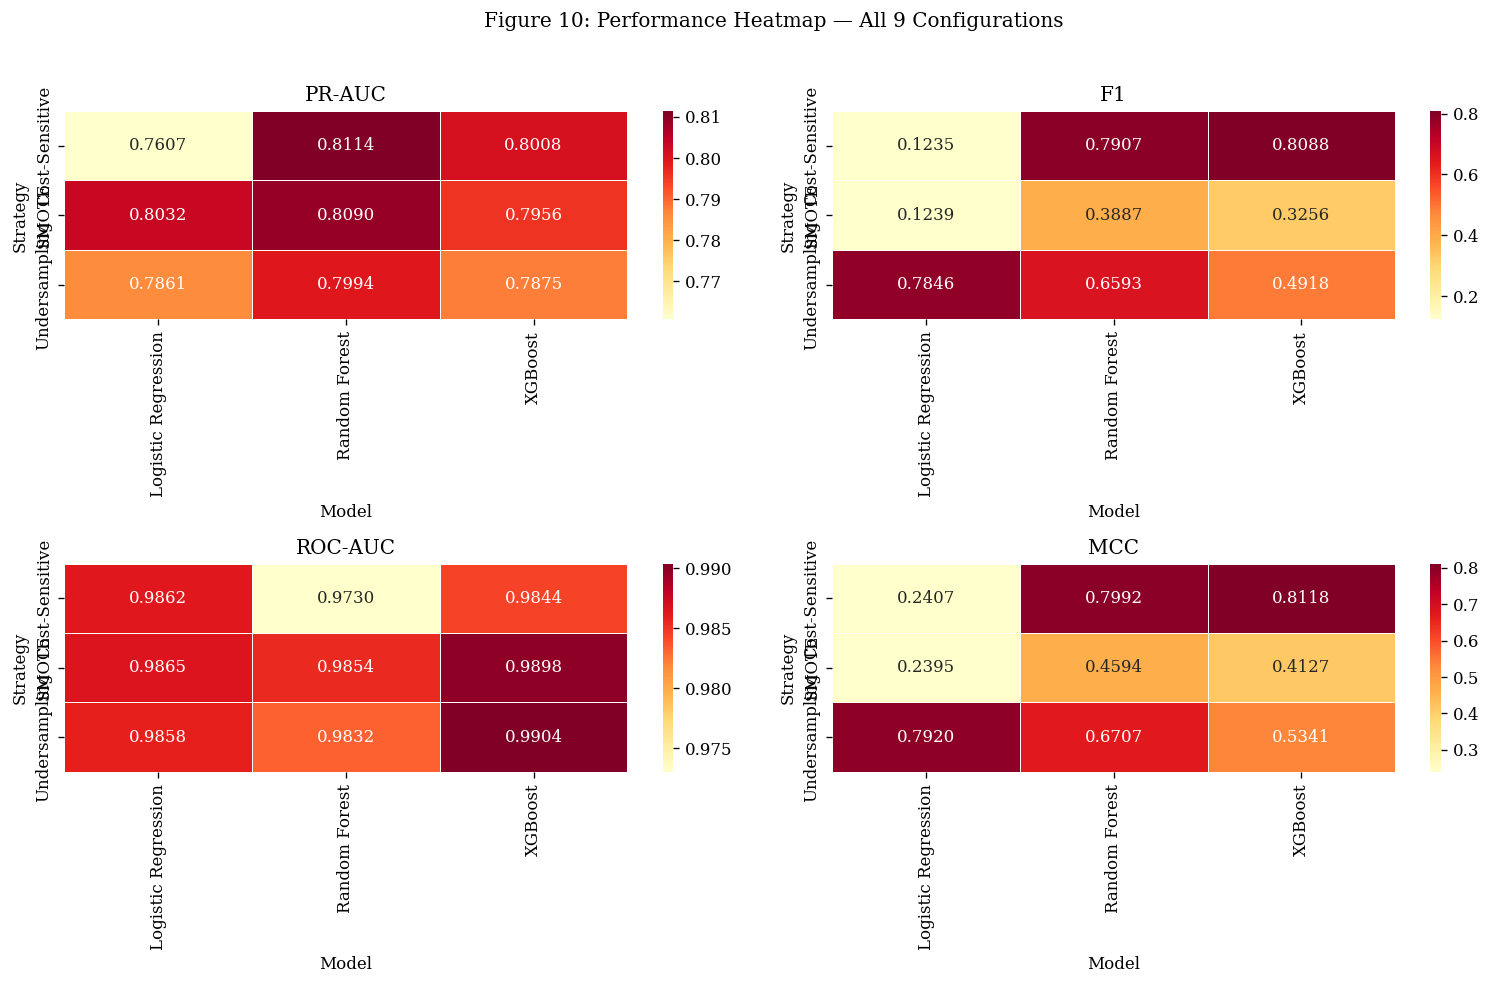

In [19]:
# Heatmap
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, metric in enumerate(['PR-AUC','F1','ROC-AUC','MCC']):
    pivot = results_df.pivot_table(index='Strategy', columns='Model', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
                ax=axes[i//2][i%2], linewidths=0.5, annot_kws={'size':10})
    axes[i//2][i%2].set_title(metric)
plt.suptitle('Figure 10: Performance Heatmap — All 9 Configurations', y=1.02)
plt.tight_layout()
plt.savefig('fig10_results_heatmap.png', bbox_inches='tight')
plt.show()

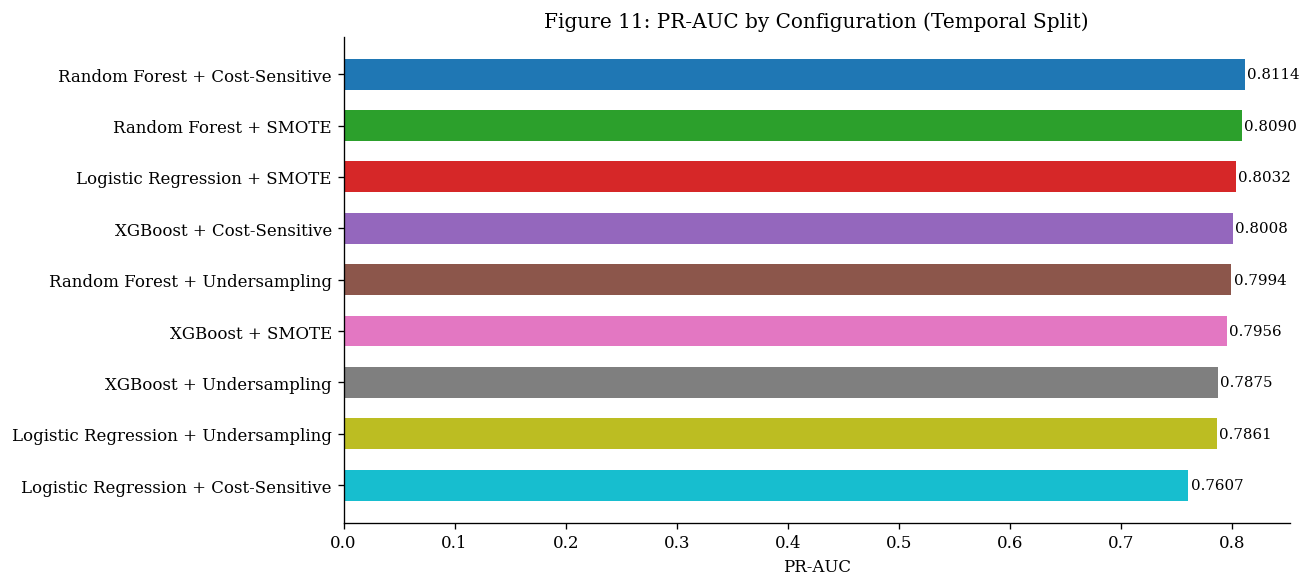

In [20]:
# Bar chart ranked by PR-AUC
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(results_df['Config'], results_df['PR-AUC'],
               color=COLORS[:9], edgecolor='none', height=0.6)
for bar, val in zip(bars, results_df['PR-AUC']):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('PR-AUC')
ax.set_title('Figure 11: PR-AUC by Configuration (Temporal Split)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig11_prauc_bar.png', bbox_inches='tight')
plt.show()

## 6. Temporal vs Random Split Comparison (RQ3)

In [21]:
df_full = pd.read_csv(BASE + 'creditcard.csv')
X_full, y_full = df_full.drop(columns=['Class']), df_full['Class']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED, stratify=y_full
)
sc = StandardScaler()
X_tr_r, X_te_r = X_tr_r.copy(), X_te_r.copy()
X_tr_r[['Time','Amount']] = sc.fit_transform(X_tr_r[['Time','Amount']])
X_te_r[['Time','Amount']] = sc.transform(X_te_r[['Time','Amount']])

print(f'Random split train: {X_tr_r.shape} Fraud={y_tr_r.sum()}')
print(f'Random split test : {X_te_r.shape} Fraud={y_te_r.sum()}')

rand_results = []
for strategy in STRATEGIES:
    Xr_bal, yr_bal = apply_imbalance_strategy(X_tr_r, y_tr_r, strategy)
    for model_name in MODELS:
        config = f'{model_name} + {strategy}'
        m = get_model(model_name, strategy)
        bp = {k:v for k,v in best_params.get(config,{}).items() if k in m.get_params()}
        m.set_params(**bp)
        m.fit(Xr_bal, yr_bal)
        ev = evaluate(m, X_te_r, y_te_r)
        rand_results.append({'Config':config,'Model':model_name,'Strategy':strategy,
                             'PR-AUC':ev['PR-AUC'],'F1':ev['F1'],
                             'ROC-AUC':ev['ROC-AUC'],'MCC':ev['MCC']})
        print(f'{config}: PR-AUC={ev["PR-AUC"]} F1={ev["F1"]}')

rand_df = pd.DataFrame(rand_results)
rand_df.to_csv('results_random.csv', index=False)

Random split train: (227845, 30) Fraud=394
Random split test : (56962, 30) Fraud=98
Logistic Regression + SMOTE: PR-AUC=0.7254 F1=0.0986
Random Forest + SMOTE: PR-AUC=0.7268 F1=0.4335
XGBoost + SMOTE: PR-AUC=0.7513 F1=0.3088
Logistic Regression + Undersampling: PR-AUC=0.7206 F1=0.7729
Random Forest + Undersampling: PR-AUC=0.7057 F1=0.6667
XGBoost + Undersampling: PR-AUC=0.7813 F1=0.5923
Logistic Regression + Cost-Sensitive: PR-AUC=0.7205 F1=0.1139
Random Forest + Cost-Sensitive: PR-AUC=0.8626 F1=0.8404
XGBoost + Cost-Sensitive: PR-AUC=0.8712 F1=0.8513


=== Temporal (T) vs Random (R) Split ===
                              Config  PR-AUC (T)  PR-AUC (R)  PR-AUC Diff
      Random Forest + Cost-Sensitive      0.8114      0.8626       0.0512
               Random Forest + SMOTE      0.8090      0.7268      -0.0822
         Logistic Regression + SMOTE      0.8032      0.7254      -0.0778
            XGBoost + Cost-Sensitive      0.8008      0.8712       0.0704
       Random Forest + Undersampling      0.7994      0.7057      -0.0937
                     XGBoost + SMOTE      0.7956      0.7513      -0.0443
             XGBoost + Undersampling      0.7875      0.7813      -0.0062
 Logistic Regression + Undersampling      0.7861      0.7206      -0.0655
Logistic Regression + Cost-Sensitive      0.7607      0.7205      -0.0402


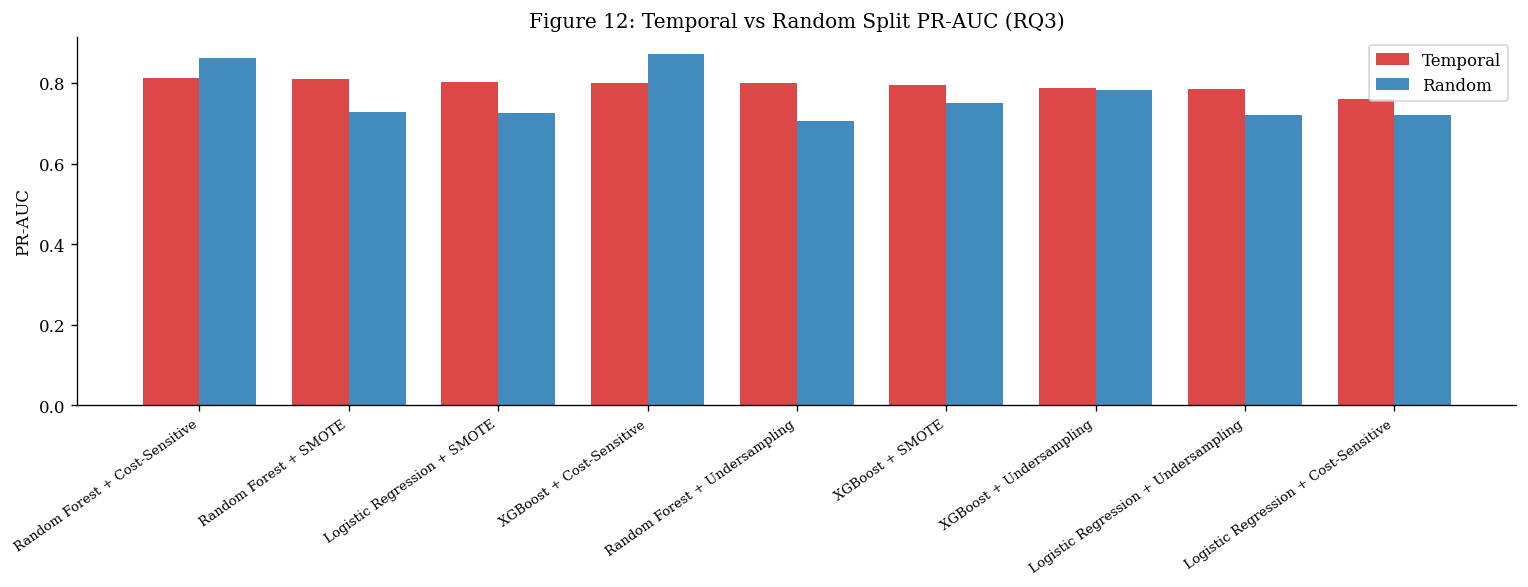

In [22]:
t = results_df[['Config','PR-AUC','F1','MCC']].rename(
    columns={'PR-AUC':'PR-AUC (T)','F1':'F1 (T)','MCC':'MCC (T)'})
r = rand_df[['Config','PR-AUC','F1','MCC']].rename(
    columns={'PR-AUC':'PR-AUC (R)','F1':'F1 (R)','MCC':'MCC (R)'})
cmp = t.merge(r, on='Config')
cmp['PR-AUC Diff'] = (cmp['PR-AUC (R)'] - cmp['PR-AUC (T)']).round(4)
print('=== Temporal (T) vs Random (R) Split ===')
print(cmp[['Config','PR-AUC (T)','PR-AUC (R)','PR-AUC Diff']].to_string(index=False))
cmp.to_csv('results_comparison.csv', index=False)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(cmp)); w = 0.38
ax.bar(x-w/2, cmp['PR-AUC (T)'], w, label='Temporal', color=FRAUD_COLOR, alpha=0.85)
ax.bar(x+w/2, cmp['PR-AUC (R)'], w, label='Random',   color=LEGIT_COLOR, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cmp['Config'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('PR-AUC')
ax.set_title('Figure 12: Temporal vs Random Split PR-AUC (RQ3)')
ax.legend()
plt.tight_layout()
plt.savefig('fig12_temporal_vs_random.png', bbox_inches='tight')
plt.show()

## 7. Threshold & Operating-Point Analysis

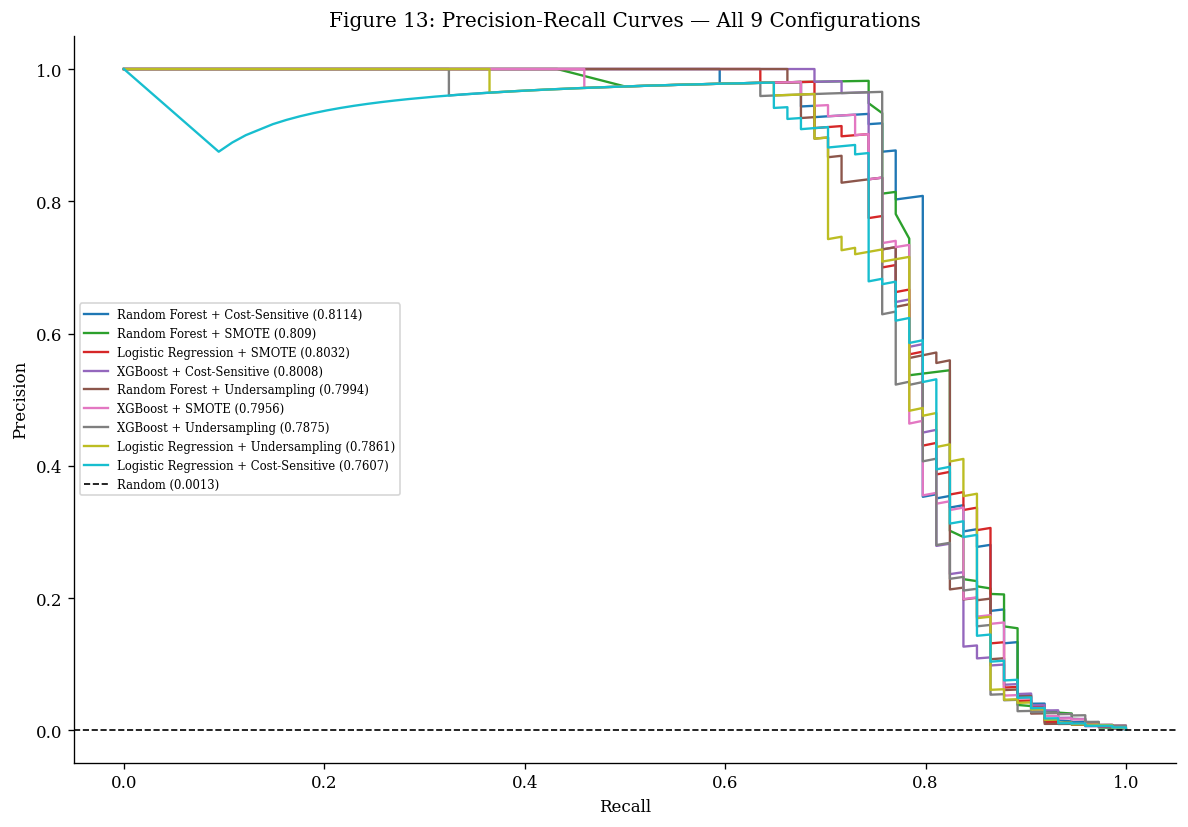

In [23]:
# PR curves all 9
fig, ax = plt.subplots(figsize=(10, 7))
for i, row in results_df.iterrows():
    yp = best_models[row['Config']].predict_proba(X_test)[:, 1]
    p, r, _ = precision_recall_curve(y_test, yp)
    ax.plot(r, p, label=f"{row['Config']} ({row['PR-AUC']})",
            color=COLORS[i], linewidth=1.4)
ax.axhline(y_test.mean(), color='black', linestyle='--', linewidth=1,
           label=f'Random ({y_test.mean():.4f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Figure 13: Precision-Recall Curves — All 9 Configurations')
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('fig13_pr_curves.png', bbox_inches='tight')
plt.show()

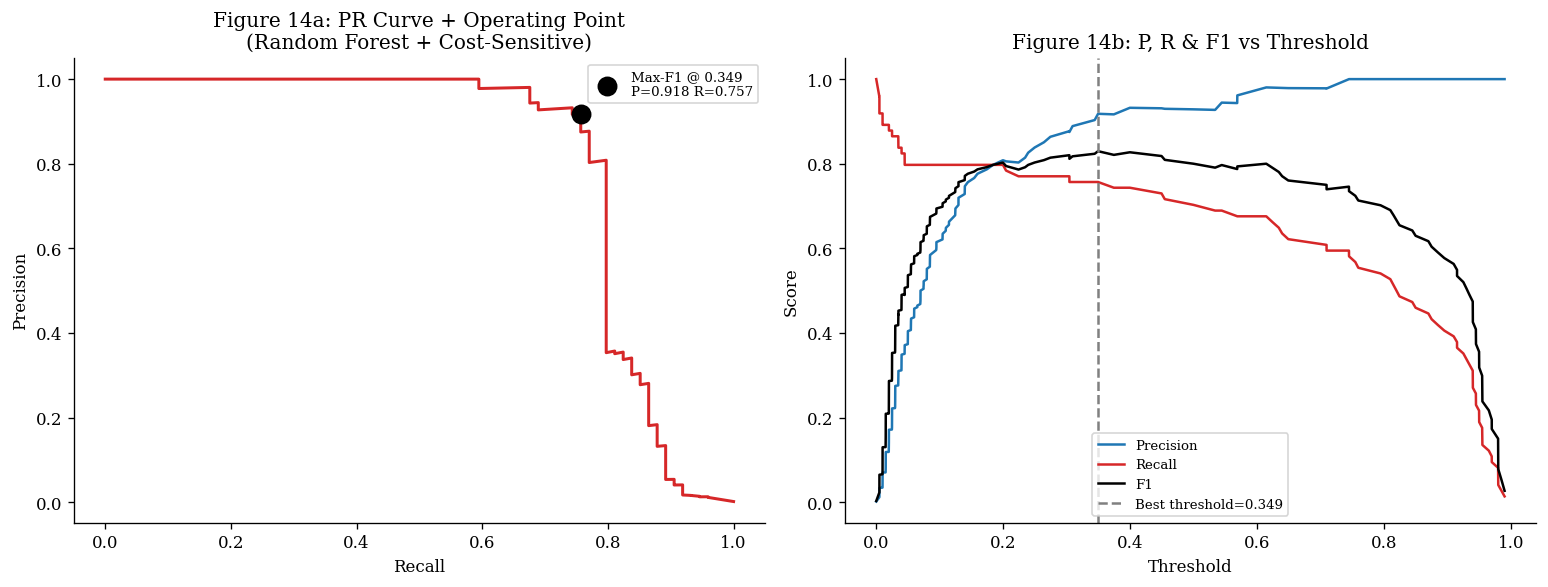

Best threshold=0.3494 | P=0.9180 R=0.7568 F1=0.8296


In [24]:
# Operating point — best model
yp_best = best_model.predict_proba(X_test)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, yp_best)
f1s = np.where((prec+rec)==0, 0, 2*prec*rec/(prec+rec))
bi  = np.argmax(f1s[:-1])
bt  = thresholds[bi]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rec, prec, color=FRAUD_COLOR, linewidth=1.8)
axes[0].scatter(rec[bi], prec[bi], s=120, color='black', zorder=5,
    label=f'Max-F1 @ {bt:.3f}\nP={prec[bi]:.3f} R={rec[bi]:.3f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'Figure 14a: PR Curve + Operating Point\n({best_config})')
axes[0].legend(fontsize=8)

axes[1].plot(thresholds, prec[:-1], label='Precision', color=LEGIT_COLOR)
axes[1].plot(thresholds, rec[:-1],  label='Recall',    color=FRAUD_COLOR)
axes[1].plot(thresholds, f1s[:-1],  label='F1',        color='black')
axes[1].axvline(bt, color='gray', linestyle='--', label=f'Best threshold={bt:.3f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Figure 14b: P, R & F1 vs Threshold')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig14_threshold_analysis.png', bbox_inches='tight')
plt.show()
print(f'Best threshold={bt:.4f} | P={prec[bi]:.4f} R={rec[bi]:.4f} F1={f1s[bi]:.4f}')

## 8. Error Analysis — FP vs FN

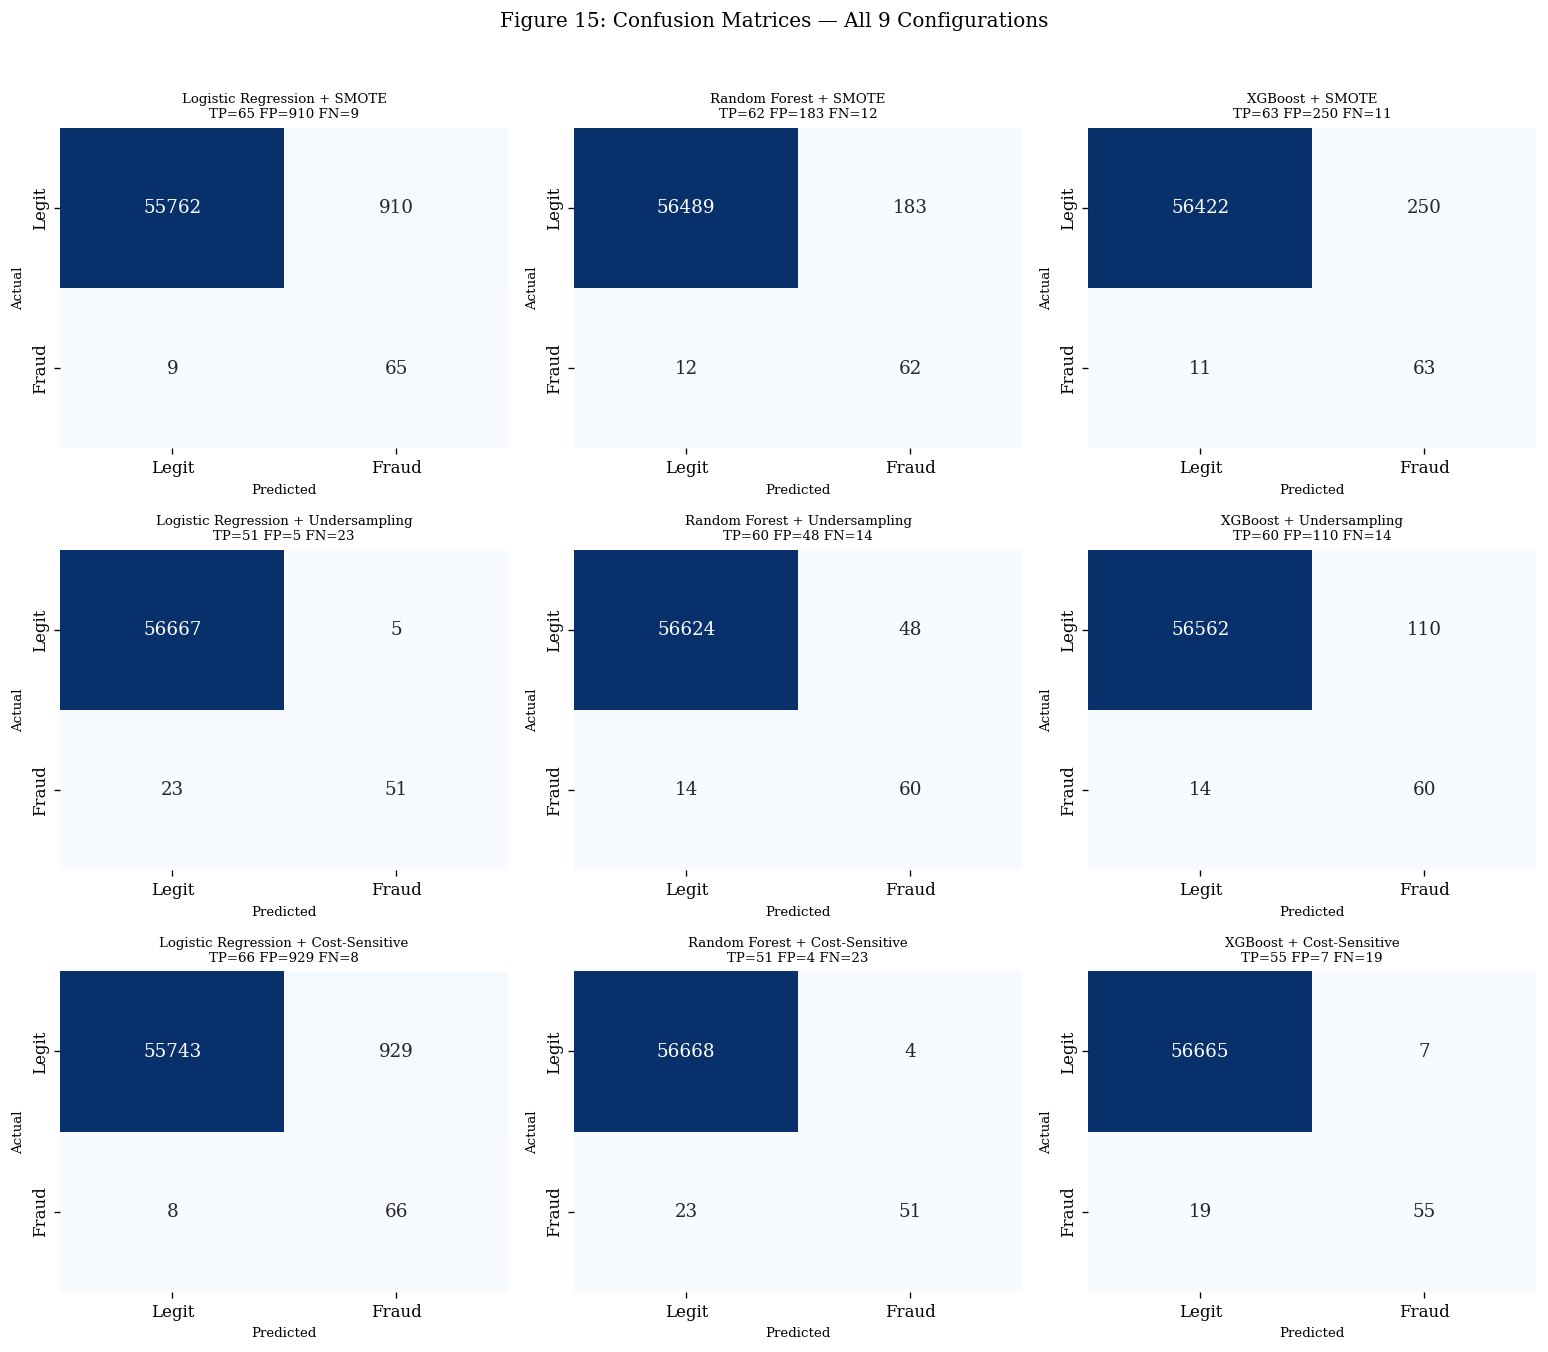

=== Error Analysis ===
                              Config  TP  FP  FN    FPR    FNR
         Logistic Regression + SMOTE  65 910   9 0.0161 0.1216
               Random Forest + SMOTE  62 183  12 0.0032 0.1622
                     XGBoost + SMOTE  63 250  11 0.0044 0.1486
 Logistic Regression + Undersampling  51   5  23 0.0001 0.3108
       Random Forest + Undersampling  60  48  14 0.0008 0.1892
             XGBoost + Undersampling  60 110  14 0.0019 0.1892
Logistic Regression + Cost-Sensitive  66 929   8 0.0164 0.1081
      Random Forest + Cost-Sensitive  51   4  23 0.0001 0.3108
            XGBoost + Cost-Sensitive  55   7  19 0.0001 0.2568

FNR = fraud missed (most costly in fraud detection)


In [25]:
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
error_rows = []

for i, (s, m) in enumerate([(s,m) for s in STRATEGIES for m in MODELS]):
    config = f'{m} + {s}'
    yd     = best_models[config].predict(X_test)
    cm     = confusion_matrix(y_test, yd)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp/(fp+tn) if (fp+tn)>0 else 0
    fnr = fn/(fn+tp) if (fn+tp)>0 else 0

    ax = axes[i//3][i%3]
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', cbar=False,
                xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'],
                annot_kws={'size':11})
    ax.set_title(f'{config}\nTP={tp} FP={fp} FN={fn}', fontsize=8)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)
    error_rows.append({'Config':config,'TP':tp,'FP':fp,'FN':fn,'TN':tn,
                       'FPR':round(fpr,4),'FNR':round(fnr,4)})

plt.suptitle('Figure 15: Confusion Matrices — All 9 Configurations', y=1.02)
plt.tight_layout()
plt.savefig('fig15_confusion_matrices.png', bbox_inches='tight')
plt.show()

error_df = pd.DataFrame(error_rows)
print('=== Error Analysis ===')
print(error_df[['Config','TP','FP','FN','FPR','FNR']].to_string(index=False))
print('\nFNR = fraud missed (most costly in fraud detection)')
error_df.to_csv('results_error_analysis.csv', index=False)

## 9. Stability Check — Variance Across Seeds

In [26]:
SEEDS = [42, 123, 999]
top3  = results_df.head(3)[['Config','Model','Strategy']].values.tolist()
stab  = []

for config, model_name, strategy in top3:
    vals = []
    for seed in SEEDS:
        Xs, ys = apply_imbalance_strategy(X_train, y_train, strategy, seed=seed)
        m = get_model(model_name, strategy, seed=seed)
        bp = {k:v for k,v in best_params.get(config,{}).items() if k in m.get_params()}
        m.set_params(**bp)
        m.fit(Xs, ys)
        p = evaluate(m, X_test, y_test)['PR-AUC']
        vals.append(p)
        stab.append({'Config':config,'Seed':seed,'PR-AUC':p})
    print(f'{config}: {np.mean(vals):.4f} ± {np.std(vals):.4f}  {vals}')

pd.DataFrame(stab).to_csv('results_stability.csv', index=False)

Random Forest + Cost-Sensitive: 0.8170 ± 0.0045  [np.float64(0.8114), np.float64(0.817), np.float64(0.8225)]
Random Forest + SMOTE: 0.8031 ± 0.0055  [np.float64(0.809), np.float64(0.7957), np.float64(0.8047)]
Logistic Regression + SMOTE: 0.7425 ± 0.0429  [np.float64(0.8032), np.float64(0.712), np.float64(0.7122)]


## 10. SHAP Explainability — Best Model (RQ4)

In [32]:
import shap

print(f'SHAP version: {shap.__version__}')
print(f'Running SHAP on: {best_config}')

X_shap = X_test.iloc[:2000].copy()
mtype = best_config.split(' + ')[0]

if mtype == 'Logistic Regression':

    bg = shap.sample(X_train, 500, random_state=SEED)
    explainer = shap.LinearExplainer(best_model, bg)

    sv_raw = explainer.shap_values(X_shap)

    sv = sv_raw

    exp_val = explainer.expected_value
    if isinstance(exp_val, (list, np.ndarray)):
        exp_val = exp_val[1] if len(exp_val) > 1 else float(exp_val[0])

else:

    explainer = shap.TreeExplainer(best_model)

    sv_raw = explainer.shap_values(X_shap)

    if isinstance(sv_raw, list):
        sv = sv_raw[1]

    elif sv_raw.ndim == 3:
        sv = sv_raw[:, :, 1]

    else:
        sv = sv_raw


    ev_raw = explainer.expected_value

    if isinstance(ev_raw, (list, np.ndarray)):
        exp_val = float(ev_raw[1]) if len(ev_raw) > 1 else float(ev_raw[0])
    else:
        exp_val = float(ev_raw)


# Safety check
assert sv.ndim == 2, f"sv should be 2D, got shape {sv.shape}"

print(f'SHAP values shape: {sv.shape} (samples x features)')
print(f'Expected value: {exp_val:.4f}')

SHAP version: 0.51.0
Running SHAP on: Random Forest + Cost-Sensitive
SHAP values shape: (2000, 30) (samples x features)
Expected value: 0.5000


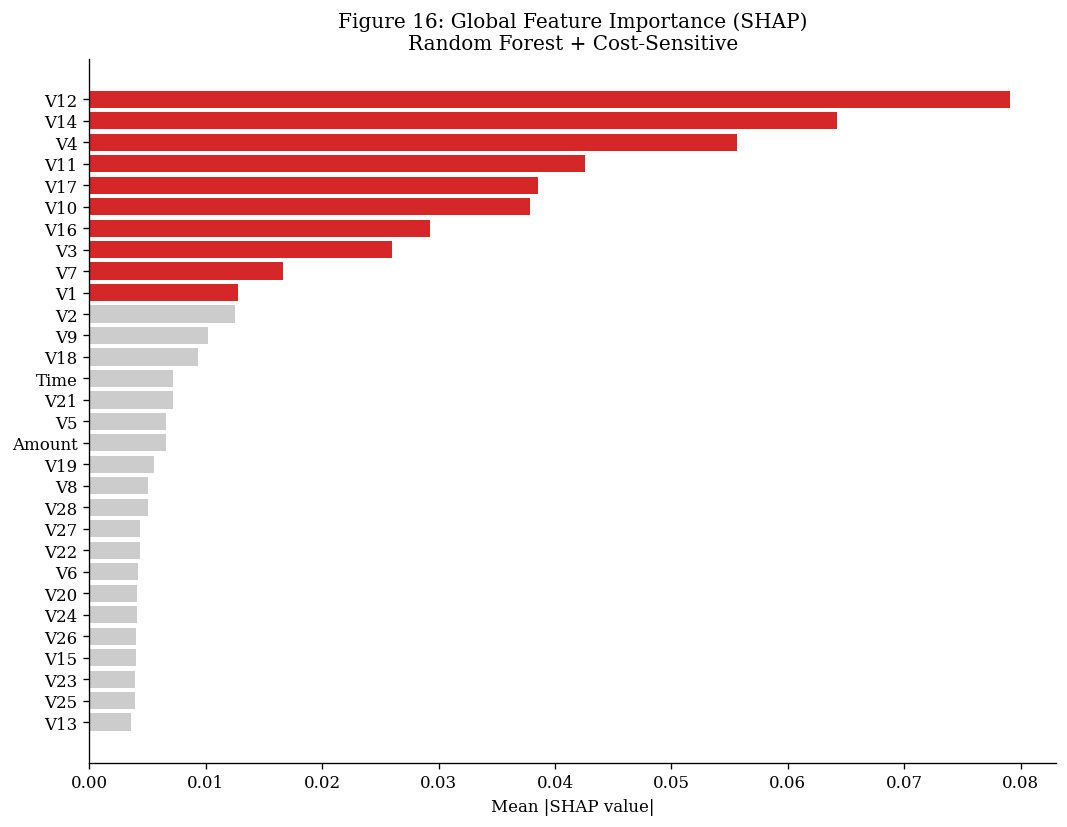

Top 10:
Feature  Mean |SHAP|
    V12     0.079081
    V14     0.064248
     V4     0.055639
    V11     0.042594
    V17     0.038514
    V10     0.037816
    V16     0.029247
     V3     0.026002
     V7     0.016629
     V1     0.012784


In [33]:
# Global importance
feat_names = X_shap.columns.tolist()
shap_imp   = pd.DataFrame({'Feature': feat_names,
                            'Mean |SHAP|': np.abs(sv).mean(axis=0)})
shap_imp   = shap_imp.sort_values('Mean |SHAP|', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
bc = [FRAUD_COLOR if i<10 else '#CCCCCC' for i in range(len(feat_names))]
ax.barh(shap_imp['Feature'], shap_imp['Mean |SHAP|'], color=bc, edgecolor='none')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Figure 16: Global Feature Importance (SHAP)\n{best_config}')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig16_shap_global.png', bbox_inches='tight')
plt.show()
print('Top 10:')
print(shap_imp.head(10).to_string(index=False))

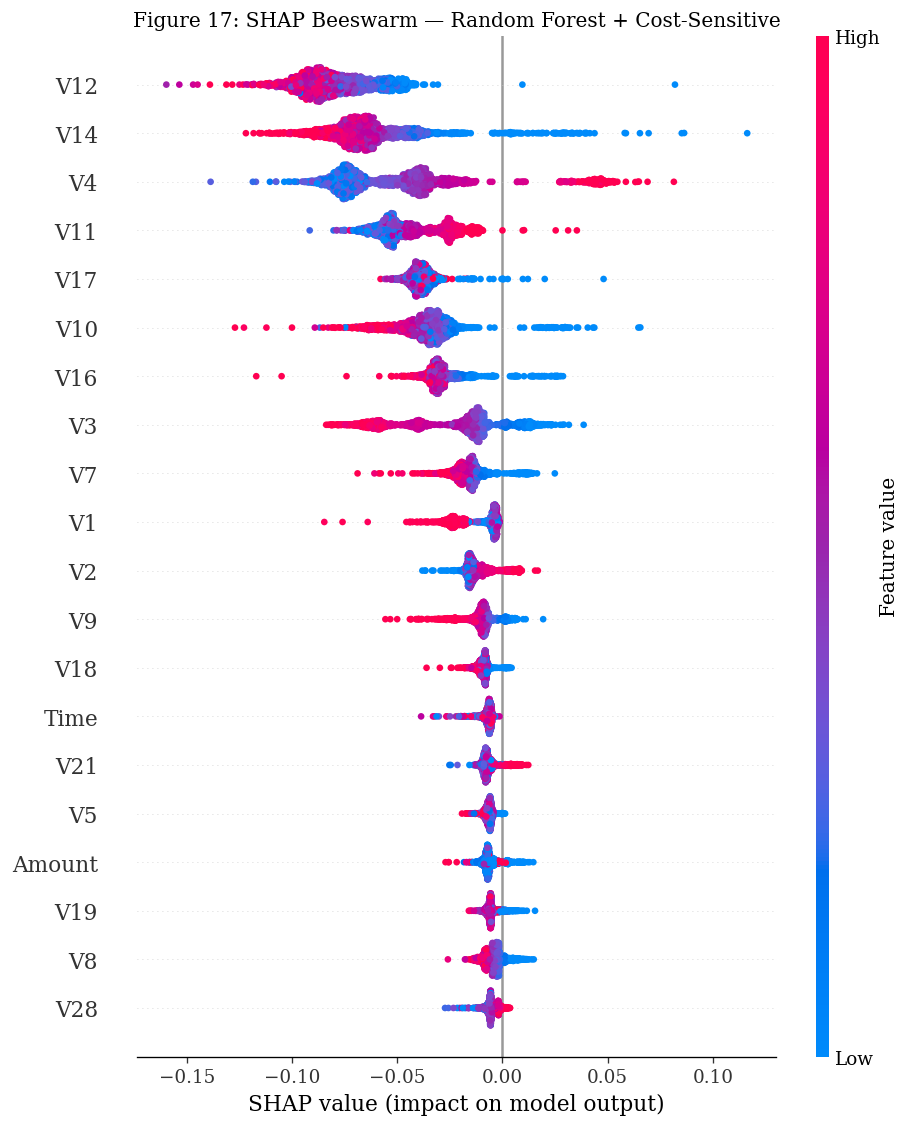

In [34]:
# Beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_shap, plot_type='dot', show=False, max_display=20)
plt.title(f'Figure 17: SHAP Beeswarm — {best_config}')
plt.tight_layout()
plt.savefig('fig17_shap_beeswarm.png', bbox_inches='tight')
plt.show()

Fraud cases in first 2000 test rows: 2


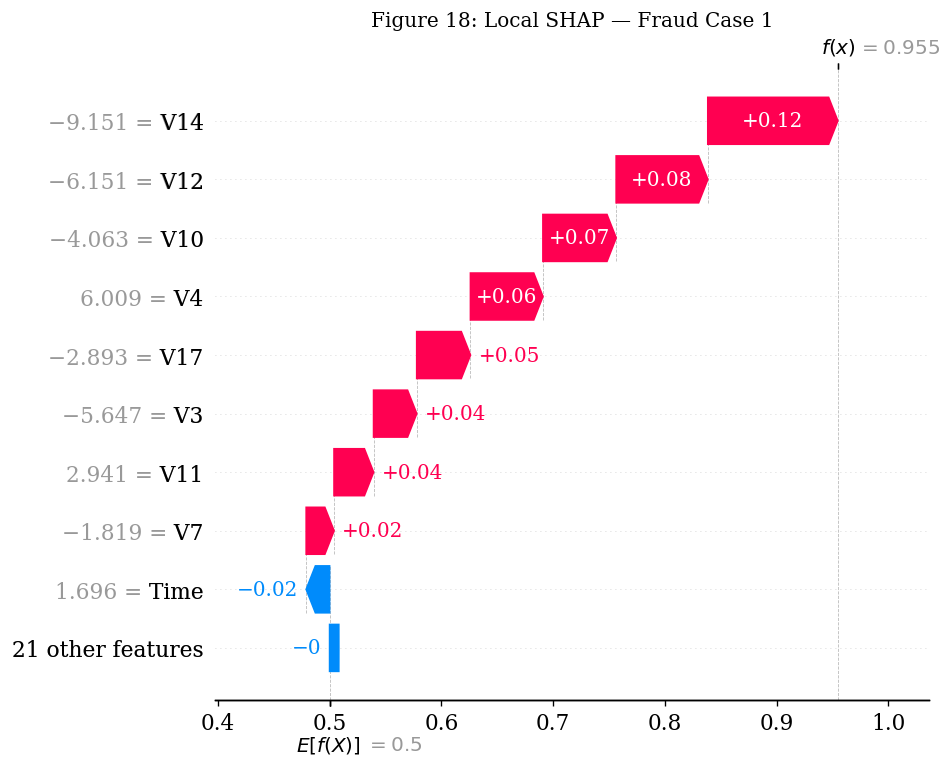

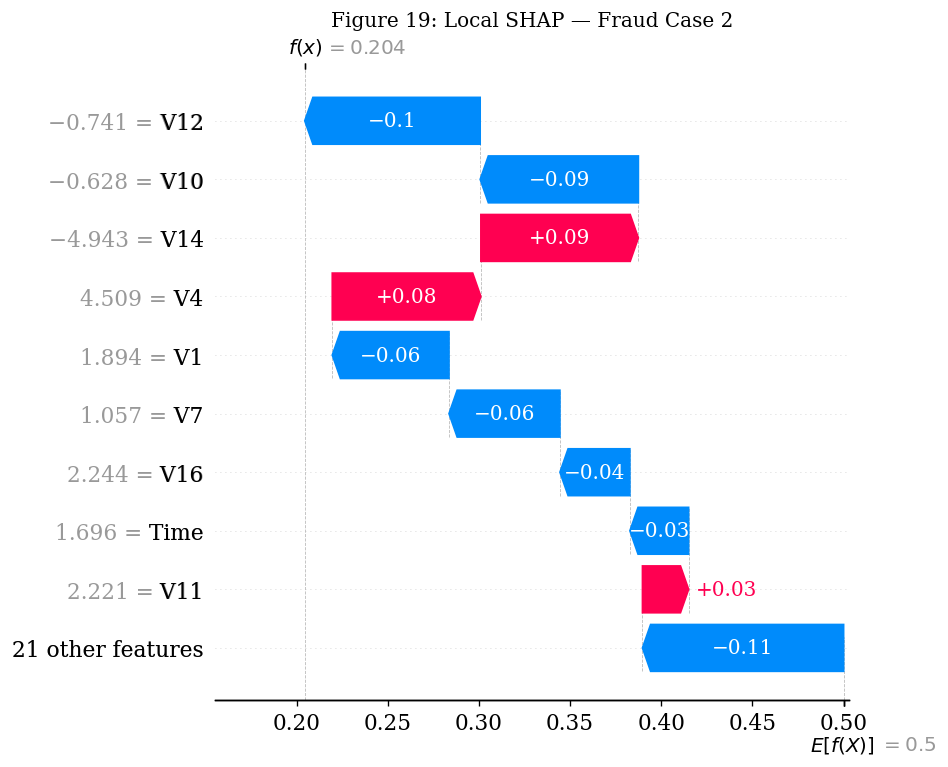

In [35]:
# Local explanations — 2 fraud cases
fraud_idx = np.where(y_test.values[:2000] == 1)[0]
print(f'Fraud cases in first 2000 test rows: {len(fraud_idx)}')
for k, idx in enumerate(fraud_idx[:2]):
    plt.figure(figsize=(10, 4))
    shap.waterfall_plot(
        shap.Explanation(
            values=sv[idx], base_values=exp_val,
            data=X_shap.iloc[idx].values,
            feature_names=feat_names
        ), show=False
    )
    plt.title(f'Figure {18+k}: Local SHAP — Fraud Case {k+1}')
    plt.tight_layout()
    plt.savefig(f'fig{18+k}_shap_local_{k+1}.png', bbox_inches='tight')
    plt.show()

## 11. Full Summary — Dissertation Chapter 5 Inputs

In [36]:
print('='*65)
print('PHASE 2 COMPLETE')
print('='*65)
print('\n--- RQ1 & RQ2: All 9 configs (Temporal Split) ---')
print(results_df[['Config','PR-AUC','F1','ROC-AUC','MCC']].to_string())
print('\n--- RQ3: Temporal vs Random ---')
print(cmp[['Config','PR-AUC (T)','PR-AUC (R)','PR-AUC Diff']].to_string(index=False))
print('\n--- Error Analysis ---')
print(error_df[['Config','TP','FP','FN','FNR']].to_string(index=False))
print('\n--- SHAP Top 5 ---')
print(shap_imp.head(5).to_string(index=False))
print('\n--- Stability ---')
stab_df = pd.read_csv('results_stability.csv')
print(stab_df.groupby('Config')['PR-AUC'].agg(['mean','std']).round(4))
print('\n--- Best threshold (best model) ---')
print(f'Threshold={bt:.4f} | P={prec[bi]:.4f} R={rec[bi]:.4f} F1={f1s[bi]:.4f}')

PHASE 2 COMPLETE

--- RQ1 & RQ2: All 9 configs (Temporal Split) ---
                                 Config  PR-AUC      F1  ROC-AUC     MCC
0        Random Forest + Cost-Sensitive  0.8114  0.7907   0.9730  0.7992
1                 Random Forest + SMOTE  0.8090  0.3887   0.9854  0.4594
2           Logistic Regression + SMOTE  0.8032  0.1239   0.9865  0.2395
3              XGBoost + Cost-Sensitive  0.8008  0.8088   0.9844  0.8118
4         Random Forest + Undersampling  0.7994  0.6593   0.9832  0.6707
5                       XGBoost + SMOTE  0.7956  0.3256   0.9898  0.4127
6               XGBoost + Undersampling  0.7875  0.4918   0.9904  0.5341
7   Logistic Regression + Undersampling  0.7861  0.7846   0.9858  0.7920
8  Logistic Regression + Cost-Sensitive  0.7607  0.1235   0.9862  0.2407

--- RQ3: Temporal vs Random ---
                              Config  PR-AUC (T)  PR-AUC (R)  PR-AUC Diff
      Random Forest + Cost-Sensitive      0.8114      0.8626       0.0512
               Random